# Proyek Akhir PKK - Kelompok 14
## MODUL 1: DATA & ENVIRONMENT SETUP
Fokus Eksekusi: Membaca struktur teksnya, dan mengonversinya menjadi matriks 2D menggunakan NumPy. Memastikan koordinat titik awal (start) dan target (goal) terpetakan dengan benar dan tidak jatuh di atas area rintangan.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import random

[INFO] Dataset './dao-map/arena.map' berhasil dimuat. Ukuran grid: 49 baris x 49 kolom.


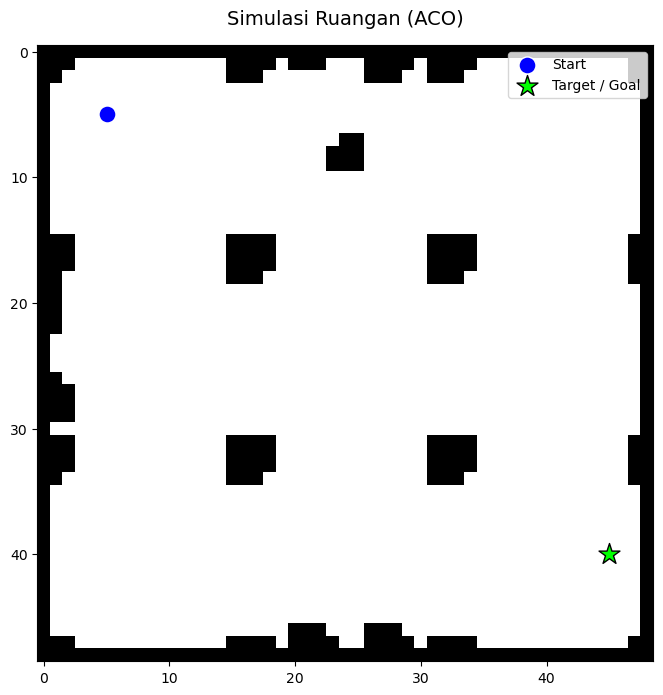

In [2]:
class EnvironmentManager:
    """
    Kelas untuk menangani ekstraksi dataset .map dan visualisasi tata letak
    untuk simulasi Ant Colony Optimization (ACO).
    """
    
    @staticmethod
    def load_moving_ai_map(filepath):
        """Membaca file .map dan mengonversinya menjadi matriks NumPy."""
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File dataset tidak ditemukan di path: {filepath}")
            
        with open(filepath, 'r') as file:
            lines = file.readlines()
            
        # Mengekstrak metadata dari header
        height = int(lines[1].strip().split(' ')[1])
        width = int(lines[2].strip().split(' ')[1])
        print(f"[INFO] Dataset '{filepath}' berhasil dimuat. Ukuran grid: {height} baris x {width} kolom.")
        
        grid = []
        # Peta selalu dimulai dari baris ke-5
        for line in lines[4:]:
            row = []
            for char in line.strip():
                # 0 merepresentasikan area yang bisa dilalui karakter
                if char in ['.', 'G', 'S']:  
                    row.append(0)
                # 1 merepresentasikan rintangan/dinding yang harus dihindari semut
                else:
                    row.append(1)
            grid.append(row)
            
        return np.array(grid)

    @staticmethod
    def visualize_grid(grid, start_node, goal_node, title="Simulasi Ruangan (ACO)"):
        """Menampilkan plot visual dari environment matriks beserta titik awal dan tujuan."""
        plt.figure(figsize=(8, 8))
        
        # Peta divisualisasikan: 0 (jalan) berwarna putih, 1 (rintangan) berwarna hitam
        plt.imshow(grid, cmap='Greys', origin='upper')
        
        # Menandai posisi Start (Biru) dan Goal (Hijau)
        # Ingat: Matplotlib (x,y) setara dengan NumPy (kolom, baris)
        plt.scatter(start_node[1], start_node[0], c='blue', marker='o', s=150, edgecolors='white', label='Start')
        plt.scatter(goal_node[1], goal_node[0], c='lime', marker='*', s=250, edgecolors='black', label='Target / Goal')
        
        plt.title(title, fontsize=14, pad=15)
        plt.legend(loc='upper right')
        plt.grid(False) # Dimatikan agar tidak mengganggu visual blok matriks
        plt.show()

# ==========================================
# BLOK EKSEKUSI (Bisa dijalankan di cell terpisah)
# ==========================================

# 1. Definisikan path file dataset Anda
# Pastikan file .map dari Moving AI berada di folder yang sama dengan file .ipynb ini
DATASET_FILE = r'./dao-map/arena.map' 

try:
    # 2. Eksekusi ekstraksi matriks
    env_manager = EnvironmentManager()
    env_matrix = env_manager.load_moving_ai_map(DATASET_FILE)
    
    # 3. Definisikan Koordinat Mulai dan Selesai
    # Format koordinat: (Baris/Y, Kolom/X)
    # PENTING: Pastikan koordinat yang dipilih bernilai 0 di dalam env_matrix
    start_pos = (5, 5)   
    target_pos = (40, 45) 
    
    # Validasi singkat agar semut tidak diletakkan di dalam tembok
    if env_matrix[start_pos[0], start_pos[1]] == 1:
        print("[PERINGATAN] Titik Start berada di dalam rintangan!")
    if env_matrix[target_pos[0], target_pos[1]] == 1:
        print("[PERINGATAN] Titik Target berada di dalam rintangan!")
        
    # 4. Tampilkan Hasil
    env_manager.visualize_grid(env_matrix, start_pos, target_pos)

except Exception as e:
    print(f"Terjadi kesalahan: {e}")

## Modul 2: Core Ant Logic Developer

In [ ]:
class Ant:
    def __init__(self, start_pos, goal_pos, env_matrix, alpha=1.0, beta=1.0):
        self.start_pos = start_pos
        self.goal_pos = goal_pos
        self.current_pos = start_pos
        self.env_matrix = env_matrix
        self.alpha = alpha           # Ini for tingkatan mengikuti feromon si semut
        self.beta = beta             # Ini semut terhadap heuristik
        self.path = [start_pos]
        self.is_stuck = False
        self.reached_goal = False
    
    def get_possible_moves(self):
        moves = []
        # 8 Directions: (Baris/Y, Kolom/X)
        directions = [
            (-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)
        ]

        for d in directions:
            new_r = self.current_pos[0] + d[0]
            new_c = self.current_pos[1] + d[1]

            # Batas di dalam dimensi matriks
            if 0 <= new_r < self.env_matrix.shape[0] and 0 <= new_c < self.env_matrix.shape[1]:
                # cek cell jalan (0) or obstacle (1)
                if self.env_matrix[new_r, new_c] == 0:
                    if (new_r, new_c) not in self.path:
                        moves.append((new_r, new_c))
        return moves

    def calculate_heuristic(self, next_pos):
        # Jarak Euclidian next_pos ke goal_pos
        dy = next_pos[0] - self.goal_pos[0]
        dx = next_pos[1] - self.goal_pos[1]
        distance = math.sqrt(dx**2 + dy**2)

        if distance == 0:
            return float('inf')

        return 1.0 / distance

    def choose_next_node(self, possible_moves, pheromone_matrix):
        # Jika ada langkah yang langsung menuju gol, langsung pilih langkah itu
        for move in possible_moves:
            if move == self.goal_pos:
                return move
            
        numerators = []
        # bobot ketertarikan (pembilang) untuk setiap opsi jalan
        for move in possible_moves:
            tau = pheromone_matrix[move[0], move[1]]
            eta = self.calculate_heuristic(move)
            
    def choose_next_node(self, possible_moves, pheromone_matrix):
        for move in possible_moves:
            if move == self.goal_pos:
                return move

        numerators = []
        # bobot ketertarikan (pembilang) untuk setiap opsi jalan
        for move in possible_moves:
            tau = pheromone_matrix[move[0], move[1]]
            eta = self.calculate_heuristic(move)
            # rumus ACO: (tau^alpha) * (eta^beta)
            score = (tau ** self.alpha) * (eta ** self.beta)
            numerators.append(score)
            
        # total bobot untuk mencari probabilitas (penyebut)
        total_score = sum(numerators)
        if total_score == 0:
            return random.choice(possible_moves)
            
        # normalisasi skor
        probabilities = [score / total_score for score in numerators]
        
        # Roulette Wheel Selection
        rand_val = random.random()
        cumulative_prob = 0.0
        
        for i, move in enumerate(possible_moves):
            cumulative_prob += probabilities[i]
            if rand_val <= cumulative_prob:
                return move
        return possible_moves[-1]

    def step(self, pheromone_matrix):
        if self.current_pos == self.goal_pos:
            self.reached_goal = True
            return

        possible_moves = self.get_possible_moves()

        if not possible_moves:
            self.is_stuck = True      # Buntu
            return

        next_pos = self.choose_next_node(possible_moves, pheromone_matrix)
        self.path.append(next_pos)
        self.current_pos = next_pos

# Test KOD

In [4]:
if __name__ == "__main__":
    dummy_env = np.zeros((10, 10))
    dummy_env[2:8, 4] = 1
    start = (1, 1)
    goal = (8, 8)
    dummy_pheromone = np.ones((10, 10))
    test_ant = Ant(start_pos=start, goal_pos=goal, env_matrix=dummy_env, alpha=1.0, beta=2.0)

    print("--- MEMULAI TES PERGERAKAN SEMUT ---")
    print(f"Posisi Awal   : {start}")
    print(f"Posisi Target : {goal}")
    print("Mulai berjalan...\n")
    
    step_count = 0
    max_steps = 100 # Batas aman agar tidak infinite loop
    
    while not test_ant.reached_goal and not test_ant.is_stuck and step_count < max_steps:
        test_ant.step(dummy_pheromone)
        step_count += 1
        print(f"Langkah {step_count}: Semut berpindah ke {test_ant.current_pos}")
        
    print("\n--- HASIL AKHIR ---")
    if test_ant.reached_goal:
        print(f"✅ SUKSES! Semut berhasil mencapai target dalam {step_count} langkah.")
        print(f"Jalur yang dilewati:\n{test_ant.path}")
    elif test_ant.is_stuck:
        print("❌ GAGAL! Semut terjebak di jalan buntu (Tabu list penuh / terhalang tembok).")
        print(f"Jalur terakhir sebelum terjebak:\n{test_ant.path}")
    else:
        print("⚠️ TIMEOUT! Semut berputar-putar terlalu lama dan mencapai batas maksimal langkah.")

--- MEMULAI TES PERGERAKAN SEMUT ---
Posisi Awal   : (1, 1)
Posisi Target : (8, 8)
Mulai berjalan...

Langkah 1: Semut berpindah ke (2, 1)
Langkah 2: Semut berpindah ke (3, 1)
Langkah 3: Semut berpindah ke (4, 2)
Langkah 4: Semut berpindah ke (3, 3)
Langkah 5: Semut berpindah ke (2, 2)
Langkah 6: Semut berpindah ke (1, 2)
Langkah 7: Semut berpindah ke (1, 3)
Langkah 8: Semut berpindah ke (0, 2)
Langkah 9: Semut berpindah ke (0, 1)
Langkah 10: Semut berpindah ke (1, 0)
Langkah 11: Semut berpindah ke (2, 0)
Langkah 12: Semut berpindah ke (3, 0)
Langkah 13: Semut berpindah ke (4, 1)
Langkah 14: Semut berpindah ke (5, 1)
Langkah 15: Semut berpindah ke (5, 2)
Langkah 16: Semut berpindah ke (6, 1)
Langkah 17: Semut berpindah ke (7, 2)
Langkah 18: Semut berpindah ke (6, 3)
Langkah 19: Semut berpindah ke (5, 3)
Langkah 20: Semut berpindah ke (6, 2)
Langkah 21: Semut berpindah ke (7, 1)
Langkah 22: Semut berpindah ke (8, 1)
Langkah 23: Semut berpindah ke (8, 0)
Langkah 24: Semut berpindah ke (7

### Pheromone & Iteration Manager

In [5]:
#Inisialisasi Matriks Feromon
class AntColony:
    def __init__(self, env_matrix, start_pos, target_pos, num_ants=20, iterations=50, 
                evaporation_rate=0.1, Q=100, alpha=1.0, beta=2.0):
        
        self.env_matrix = env_matrix
        self.start_pos = start_pos
        self.target_pos = target_pos
        
        # Hyperparameter ACO
        self.num_ants = num_ants
        self.iterations = iterations
        self.evaporation_rate = evaporation_rate
        self.Q = Q
        self.alpha = alpha
        self.beta = beta
        
        # Matriks feromon awal (jangan 0 agar rumus pembagian/perkalian jalan)
        self.pheromone_matrix = np.ones(env_matrix.shape) * 0.1 
        
        # Variabel untuk menyimpan rekor jalur terbaik
        self.global_best_path = None
        self.global_best_length = float('inf')
        
    def run(self):
        """Fungsi utama untuk menjalankan simulasi ACO"""
        print("[INFO] Memulai Simulasi Ant Colony Optimization...")
        
        for it in range(self.iterations):
            successful_paths = []
            
            # 1. Lepaskan sekumpulan semut
            for _ in range(self.num_ants):
                ant = Ant(self.start_pos, self.target_pos, self.env_matrix, self.alpha, self.beta)
                
                step_count = 0
                # Biarkan semut berjalan sampai tujuan / buntu / batas langkah
                while not ant.reached_goal and not ant.is_stuck and step_count < 1000:
                    ant.step(self.pheromone_matrix)
                    step_count += 1
                
                # Jika sukses, catat jalurnya
                if ant.reached_goal:
                    successful_paths.append(ant.path)
                    
                    # Cek apakah ini jalur terbaik yang pernah ditemukan
                    if len(ant.path) < self.global_best_length:
                        self.global_best_length = len(ant.path)
                        self.global_best_path = ant.path
            
            # 2. Update Feromon setelah semua semut di iterasi ini selesai
            self.update_pheromones(successful_paths)
            
            print(f"Iterasi {it+1}/{self.iterations} | Semut Sukses: {len(successful_paths)} | Jarak Terbaik Sementara: {self.global_best_length}")
            
        return self.global_best_path, self.global_best_length
    def update_pheromones(self, successful_paths):
        """Menerapkan penguapan dan penambahan feromon"""
        # Tahap 1: Penguapan (Evaporation) ---
        self.pheromone_matrix *= (1.0 - self.evaporation_rate)
        
        # Tahap 2: Penambahan (Deposition) ---
        for path in successful_paths:
            L = len(path)
            delta_tau = self.Q / L
            
            for (r, c) in path:
                # Tambahkan feromon ke koordinat yang dilewati (kecuali mungkin tembok/batas)
                self.pheromone_matrix[r, c] += delta_tau

In [ ]:
if __name__ == "__main__":
    # 1. SETUP ENVIRONMENT
    DATASET_FILE = r'./dao-map/arena.map' 
    env_manager = EnvironmentManager()
    
    try:
        # Load peta menjadi matriks
        env_matrix = env_manager.load_moving_ai_map(DATASET_FILE)
        
        # Definisikan koordinat (Baris, Kolom)
        start_pos = (5, 5)   
        target_pos = (40, 45)
        
        # Validasi start/goal
        if env_matrix[start_pos[0], start_pos[1]] == 1 or env_matrix[target_pos[0], target_pos[1]] == 1:
            raise ValueError("Titik Start atau Target berada di dalam rintangan!")
            
        # 2. INISIALISASI DAN EKSEKUSI ACO
        # Parameter di bawah ini nantinya yang akan diubah-ubah oleh temanmu (Tuning)
        colony = AntColony(
            env_matrix=env_matrix, 
            start_pos=start_pos, 
            target_pos=target_pos, 
            num_ants=20,          # Jumlah semut per iterasi
            iterations=50,        # Total iterasi
            evaporation_rate=0.1, # Persentase penguapan feromon (rho)
            Q=100,                # Konstanta penambahan feromon
            alpha=1.0,            # Bobot feromon
            beta=2.0              # Bobot heuristik (jarak)
        )
        
        # Menjalankan mesin iterasi utama
        best_path, best_length = colony.run()
        
        # 3. HANDOVER KE VISUALIZER
        print("\n" + "="*40)
        print("--- HASIL AKHIR SIMULASI ACO ---")
        if best_path:
            print(f"Status: SUKSES!")
            print(f"Jalur Terpendek Ditemukan: {best_length} langkah")
            print("Data 'env_matrix', 'start_pos', 'target_pos', dan 'best_path' siap divisualisasikan.")
            
            # Temanmu tinggal memanggil fungsi visualisasi dengan data di atas,
            # misalnya: env_manager.visualize_best_route(env_matrix, start_pos, target_pos, best_path)
            
        else:
            print("Status: GAGAL")
            print("Semut tidak berhasil menemukan target dalam jumlah iterasi yang diberikan.")
            print("Saran Tuning: Tambah jumlah semut, iterasi, atau sesuaikan nilai alpha/beta.")
            
    except Exception as e:
        print(f"Terjadi kesalahan sistem: {e}")

[INFO] Dataset './dao-map/arena.map' berhasil dimuat. Ukuran grid: 49 baris x 49 kolom.
[INFO] Memulai Simulasi Ant Colony Optimization...
Iterasi 1/50 | Semut Sukses: 2 | Jarak Terbaik Sementara: 242
Iterasi 2/50 | Semut Sukses: 4 | Jarak Terbaik Sementara: 213
Iterasi 3/50 | Semut Sukses: 1 | Jarak Terbaik Sementara: 182
Iterasi 4/50 | Semut Sukses: 1 | Jarak Terbaik Sementara: 176
Iterasi 5/50 | Semut Sukses: 3 | Jarak Terbaik Sementara: 148
Iterasi 6/50 | Semut Sukses: 3 | Jarak Terbaik Sementara: 148
Iterasi 7/50 | Semut Sukses: 2 | Jarak Terbaik Sementara: 148
Iterasi 8/50 | Semut Sukses: 2 | Jarak Terbaik Sementara: 148
Iterasi 9/50 | Semut Sukses: 1 | Jarak Terbaik Sementara: 148
Iterasi 10/50 | Semut Sukses: 2 | Jarak Terbaik Sementara: 148
Iterasi 11/50 | Semut Sukses: 0 | Jarak Terbaik Sementara: 148
Iterasi 12/50 | Semut Sukses: 2 | Jarak Terbaik Sementara: 130
Iterasi 13/50 | Semut Sukses: 3 | Jarak Terbaik Sementara: 130
Iterasi 14/50 | Semut Sukses: 3 | Jarak Terbaik Sem